In [1]:
# ============================================================
# TECH CHALLENGE FASE 1 — PosTech/FIAP
# Classificação de Síndrome dos Ovários Policísticos (SOP)
# com Machine Learning
# ============================================================

# Etapa 1 — Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import joblib
import shap

print("✅ Bibliotecas carregadas com sucesso!")

c:\Users\sabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Bibliotecas carregadas com sucesso!


In [2]:
# Etapa 2 — Carregando o dataset
df = pd.read_excel("PCOS_data_without_infertility.xlsx", sheet_name=1)

print("✅ Dataset carregado com sucesso!")
print("Shape:", df.shape)
df.head()

✅ Dataset carregado com sucesso!
Shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [3]:
# Etapa 3 — Inspeção inicial
print("Informações do dataset:")
print(df.info())
print("\nValores ausentes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 n

In [5]:
# Etapa 4 — Limpeza dos dados

# Removendo coluna inútil
df = df.drop(columns=['Unnamed: 44'])

# Limpando espaços nos nomes das colunas
df.columns = df.columns.str.strip()

# Preenchendo valor vazio de Marraige Status com a média
media = df['Marraige Status (Yrs)'].mean()
df['Marraige Status (Yrs)'] = df['Marraige Status (Yrs)'].fillna(media)

# Preenchendo valor vazio de Fast food com a moda
moda = df['Fast food (Y/N)'].mode()[0]
df['Fast food (Y/N)'] = df['Fast food (Y/N)'].fillna(moda)

print("✅ Limpeza concluída!")
print("Valores ausentes restantes:", df.isnull().sum().sum())
print("Shape após limpeza:", df.shape)

✅ Limpeza concluída!
Valores ausentes restantes: 0
Shape após limpeza: (541, 44)


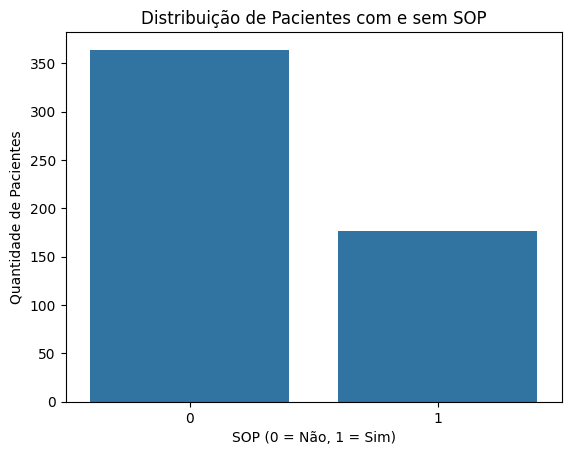

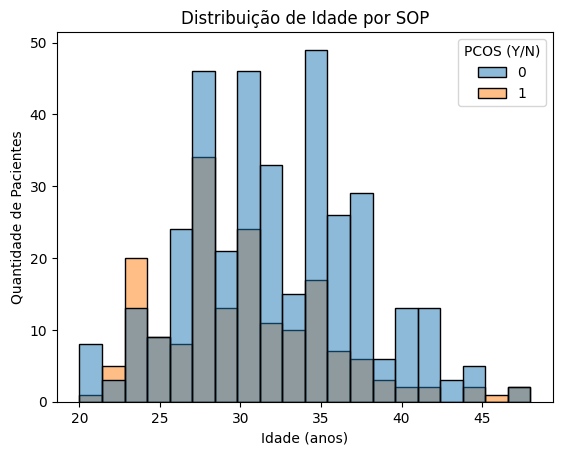

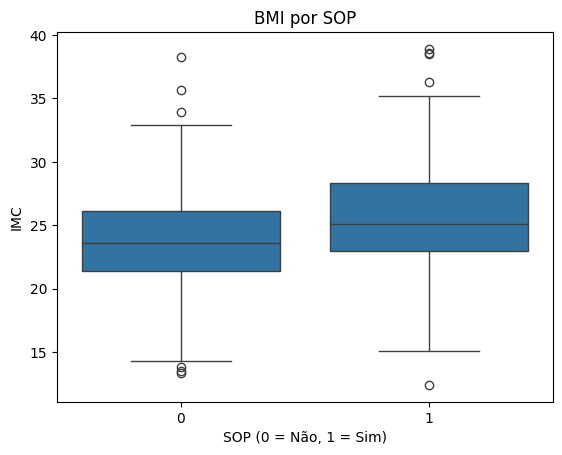

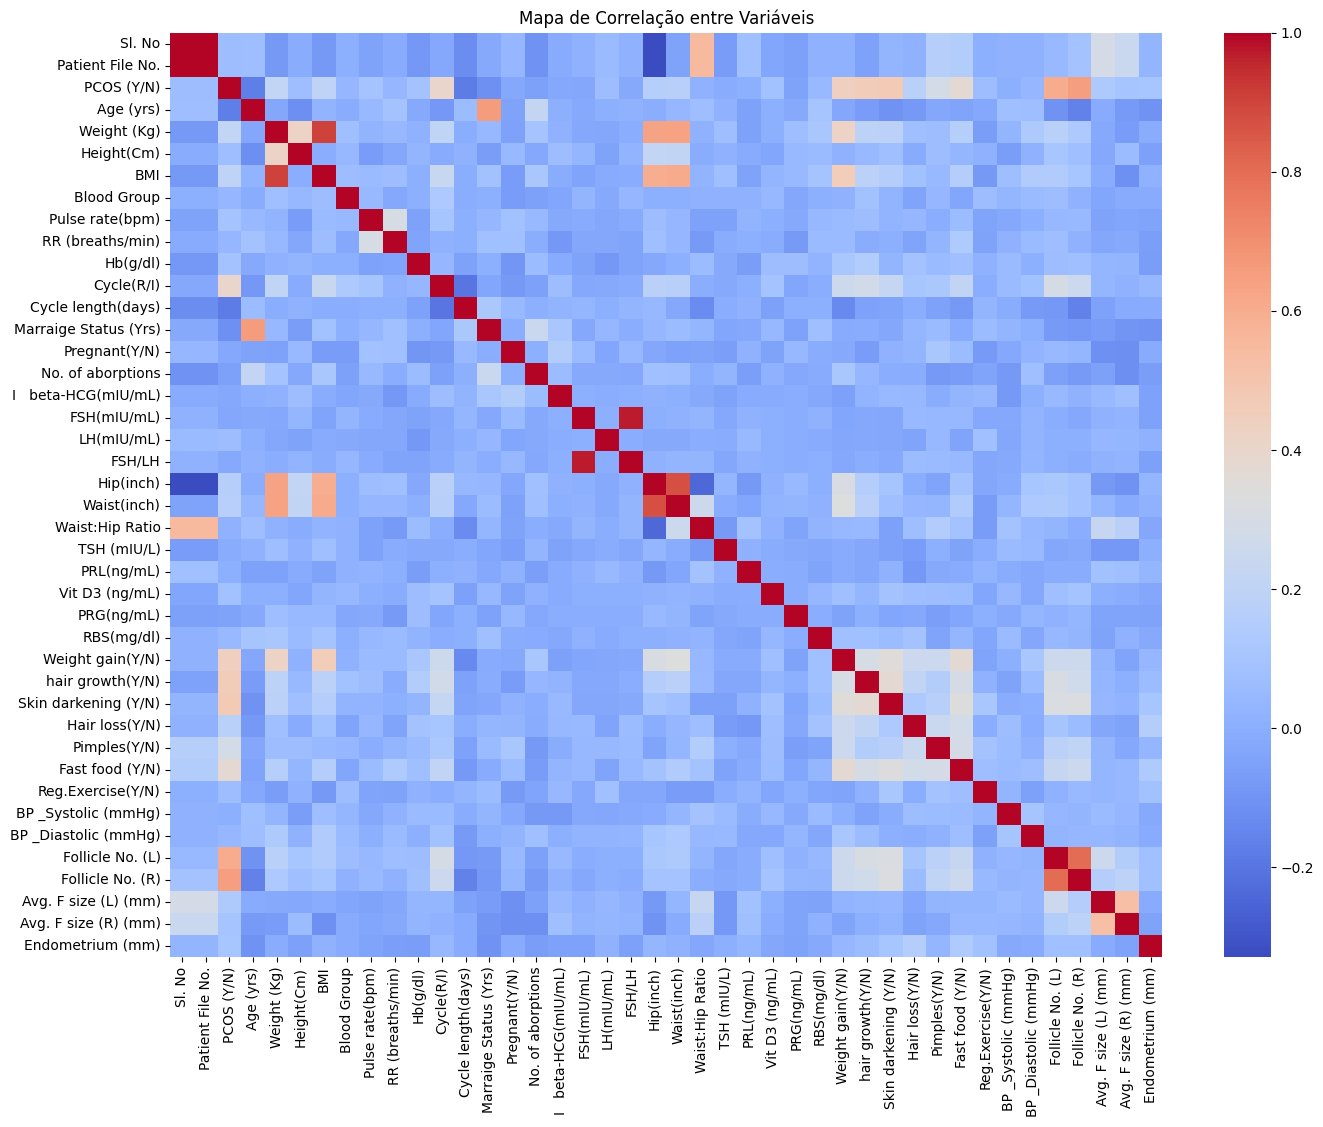

In [7]:
# Etapa 5 — Análise Exploratória

# Gráfico 1: Distribuição de pacientes com e sem SOP
sns.countplot(x='PCOS (Y/N)', data=df)
plt.title('Distribuição de Pacientes com e sem SOP')
plt.xlabel('SOP (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Pacientes')
plt.show()

# Gráfico 2: Distribuição de idade por SOP
sns.histplot(data=df, x='Age (yrs)', hue='PCOS (Y/N)', bins=20)
plt.title('Distribuição de Idade por SOP')
plt.xlabel('Idade (anos)')
plt.ylabel('Quantidade de Pacientes')
plt.show()

# Gráfico 3: BMI por SOP
sns.boxplot(x='PCOS (Y/N)', y='BMI', data=df)
plt.title('BMI por SOP')
plt.xlabel('SOP (0 = Não, 1 = Sim)')
plt.ylabel('IMC')
plt.show()

# Gráfico 4: Mapa de correlação
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Mapa de Correlação entre Variáveis')
plt.show()

In [9]:
# Etapa 6 — Pré-processamento

# Removendo colunas de identificação
df = df.drop(columns=['Sl. No', 'Patient File No.'])

# Separando X (entradas) e y (alvo)
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

# Convertendo colunas de texto para número
X = X.copy()
X['II    beta-HCG(mIU/mL)'] = pd.to_numeric(X['II    beta-HCG(mIU/mL)'], errors='coerce')
X['AMH(ng/mL)'] = pd.to_numeric(X['AMH(ng/mL)'], errors='coerce')
X['II    beta-HCG(mIU/mL)'] = X['II    beta-HCG(mIU/mL)'].fillna(X['II    beta-HCG(mIU/mL)'].mean())
X['AMH(ng/mL)'] = X['AMH(ng/mL)'].fillna(X['AMH(ng/mL)'].mean())

print("✅ Pré-processamento concluído!")
print("Shape X:", X.shape)
print("Colunas object restantes:", X.dtypes[X.dtypes == 'object'].count())

✅ Pré-processamento concluído!
Shape X: (541, 41)
Colunas object restantes: 0


In [10]:
# Etapa 7 — Separando treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Dados separados!")
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

✅ Dados separados!
Treino: (432, 41)
Teste: (109, 41)


In [11]:
# Etapa 8 — Treinando os modelos

# Modelo 1: Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)
print("✅ Árvore de Decisão treinada!")

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
print("✅ Random Forest treinada!")

# Previsões
y_pred_arvore = modelo_arvore.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)
print("✅ Previsões geradas!")

✅ Árvore de Decisão treinada!
✅ Random Forest treinada!
✅ Previsões geradas!


In [12]:
# Etapa 9 — Avaliando os modelos

print("🌳 ÁRVORE DE DECISÃO:")
print(classification_report(y_test, y_pred_arvore))

print("🌲 RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf))

🌳 ÁRVORE DE DECISÃO:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        73
           1       0.85      0.81      0.83        36

    accuracy                           0.89       109
   macro avg       0.88      0.87      0.87       109
weighted avg       0.89      0.89      0.89       109

🌲 RANDOM FOREST:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        73
           1       0.93      0.78      0.85        36

    accuracy                           0.91       109
   macro avg       0.92      0.88      0.89       109
weighted avg       0.91      0.91      0.91       109



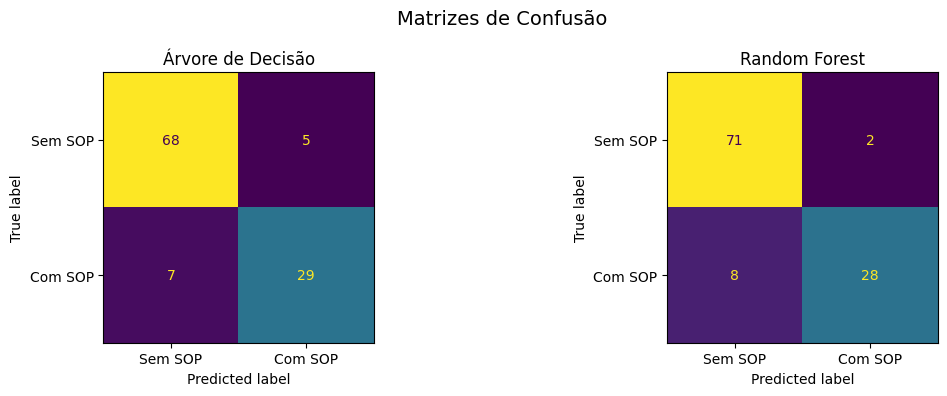

In [13]:
# Etapa 10 — Matrizes de Confusão

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_arvore,
    display_labels=['Sem SOP', 'Com SOP'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Árvore de Decisão')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Sem SOP', 'Com SOP'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest')

plt.suptitle('Matrizes de Confusão', fontsize=14)
plt.tight_layout()
plt.show()

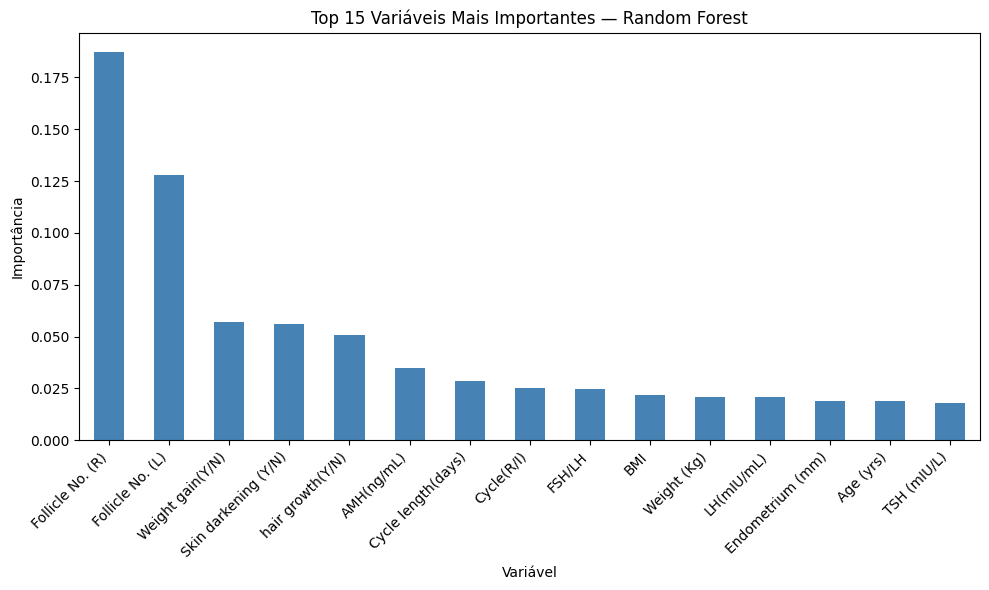

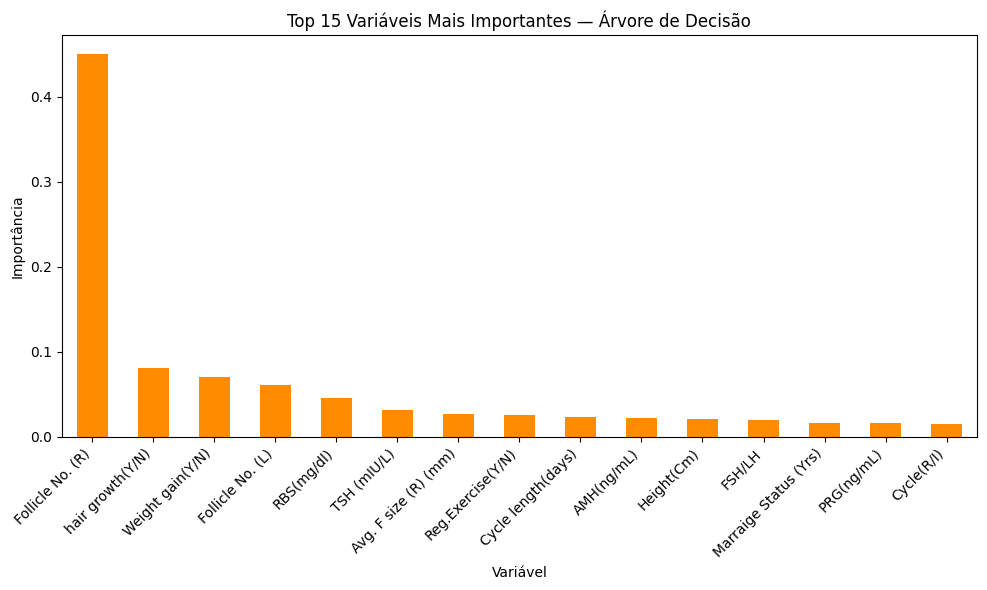

In [14]:
# Etapa 11 — Feature Importance

# Random Forest
importancias_rf = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias_rf.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis Mais Importantes — Random Forest')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Árvore de Decisão
importancias_arvore = pd.Series(
    modelo_arvore.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias_arvore.head(15).plot(kind='bar', color='darkorange')
plt.title('Top 15 Variáveis Mais Importantes — Árvore de Decisão')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

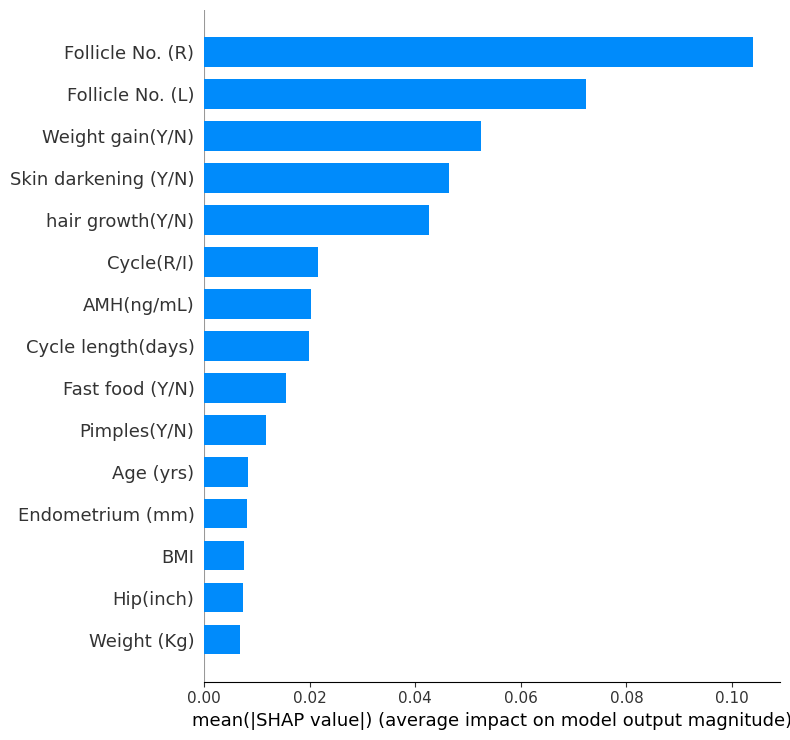

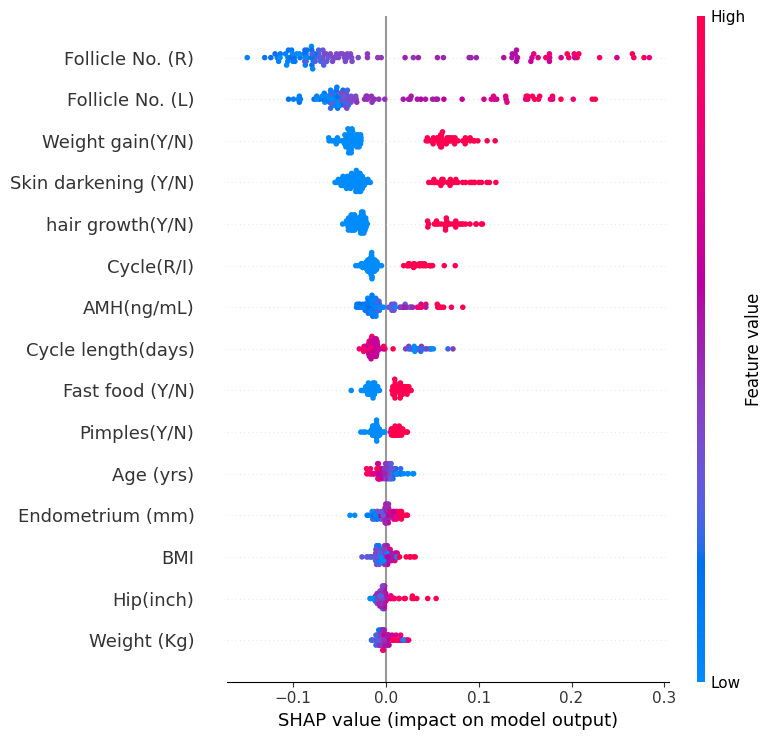

In [15]:
# Etapa 12 — SHAP Values

explicador = shap.TreeExplainer(modelo_rf)
shap_values = explicador.shap_values(X_test)

# Gráfico de barras — importância global
shap.summary_plot(shap_values[:, :, 1], X_test,
                  plot_type="bar",
                  max_display=15)

# Beeswarm plot — efeito de cada variável
shap.summary_plot(shap_values[:, :, 1], X_test,
                  max_display=15)

In [16]:
# Etapa 13 — Salvando os modelos

joblib.dump(modelo_rf, 'modelo_pcos_random_forest.pkl')
joblib.dump(modelo_arvore, 'modelo_pcos_arvore_decisao.pkl')

print("✅ Modelos salvos com sucesso!")
print("📁 modelo_pcos_random_forest.pkl")
print("📁 modelo_pcos_arvore_decisao.pkl")

✅ Modelos salvos com sucesso!
📁 modelo_pcos_random_forest.pkl
📁 modelo_pcos_arvore_decisao.pkl
